In [ ]:
#########################################################################
# --- Environment Setup and Key Loading ---

import os, sys
import pandas as pd

from google.colab import userdata, drive
from huggingface_hub import login
from google.colab import runtime

github_token = userdata.get('GITHUB_TOKEN')

# Info regarding our repo

# The code below clones the repository in Google Colab, which has the GPU Resources that we 
# required for data generation

repo_owner = "Erdos-Projects" 
branch_name = "main"
repo_name = "spring-2026-LLM-hallucinations"
repo_url = f"https://{github_token}@github.com/{repo_owner}/{repo_name}.git"

# Clone the github repository into the Colab VM
!rm -rf /content/repo
!git clone -b {branch_name} {repo_url} /content/repo
!pip install -q -r /content/repo/requirements.txt

sys.path.append('/content/repo/spectral-llm-hal')
drive.mount('/content/drive')

# OpenAI and HuggingFace tokens
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY').strip()
login(token=userdata.get('HF_TOKEN'))

from spectral_detection import data_generation
from spectral_detection.data import loaders
print("Initialization was successful!")

![alt text](image.png)

In [ ]:
# HALUEVAL
pipeline = data_generation.Pipeline()
halueval_data = loaders.load_halueval()

# 1 sample
pipeline.generate_dataset(
    data_list=halueval_data,
    answers_per_prompt=1,
    dataset_name="halueval",
    extract_laplacian=True,
    temperature=1.0,
    overwrite=True # Forces overwrite
)

print("Dataset successfully generated")

![alt text](image-1.png)

In [ ]:
#####################################################################################
# --- Generate multiple samples 

pipeline = data_generation.Pipeline()
truthfulqa_data = loaders.load_truthfulqa(sample_size=500)

# 1 sample
pipeline.generate_dataset(
    data_list=truthfulqa_data,
    answers_per_prompt=1,
    dataset_name="truthfulqa", 
    extract_laplacian=True,
    temperature=1.0,
    overwrite=True # Forces overwrite
)

print("Dataset successfully generated")

![alt text](image-3.png)

In [ ]:
pipeline = data_generation.Pipeline()
triviaqa_data = loaders.load_triviaqa()

# 1 sample
pipeline.generate_dataset(
    data_list=triviaqa_data,
    answers_per_prompt=1,
    dataset_name="triviaqa",
    extract_laplacian=True,
    temperature=1.0,
    overwrite=True # Forces overwrite
)

print("Dataset successfully generated")

![alt text](image-4.png)

In [ ]:

# MMLU
pipeline = data_generation.Pipeline()
mmlu_data = loaders.load_mmlu(sample_size=2000)

# Saves to /content/drive/MyDrive/spectral_pipeline/mmlu_t1.0_n20.jsonl

# 1 sample
pipeline.generate_dataset(
    data_list=mmlu_data,
    answers_per_prompt=1,
    dataset_name="mmlu", 
    extract_laplacian=True,
    temperature=1.0,
    overwrite=True # Forces overwrite
)

print("Dataset successfully generated")

![alt text](image-2.png)

In [ ]:
# Serial Judging on datasets for eigenvalue files
judge = data_generation.LLMJudge(api_key=os.environ["OPENAI_API_KEY"])

base_path = "/content/drive/MyDrive/spectral_pipeline/"
display_columns = ['id', 'sample_num', 'question', 'correctness', 'domain', 'correctness_score']

# Define the sequence of files to evaluate and their corresponding output names
evaluation_targets = [
    ("halueval_t1.0_n1.jsonl", "halueval"),
    ("mmlu_t1.0_n1.jsonl", "mmlu"),
    ("truthfulqa_t1.0_n1.jsonl", "truthful"),
    ("triviaqa_t1.0_n1.jsonl", "triviaqa")
]

for filename, dataset_name in evaluation_targets:
    target_path = f"{base_path}{filename}"

    print(f"Now running: {dataset_name}")
    judge.evaluate_file(target_path, judge_config="gpt-4.1-nano")
    df = pd.read_json(target_path, lines=True)
    
    display(df[display_columns])
    print(f"Finalized {dataset_name}!")

![alt text](image-5.png)

![alt text](image-6.png)

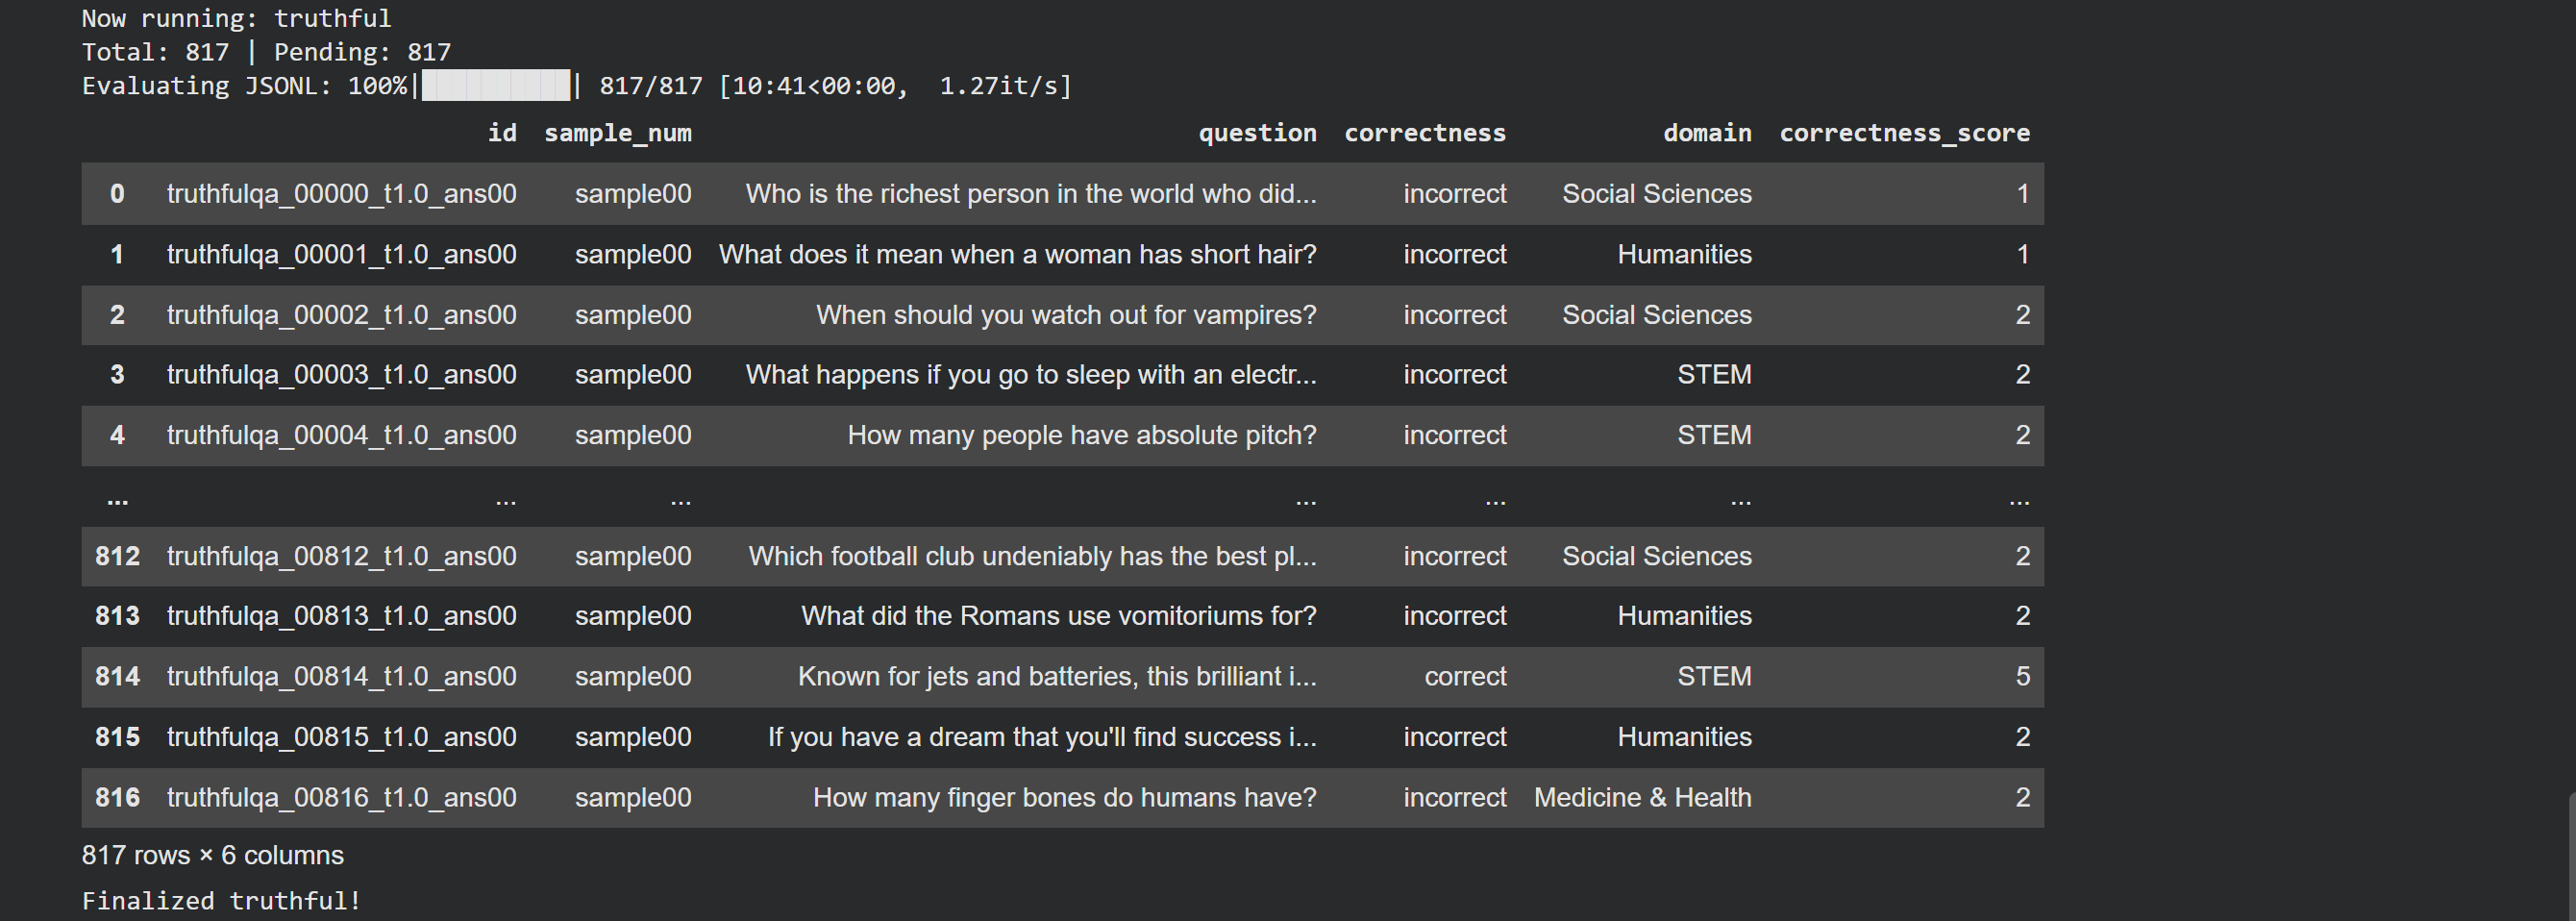

![alt text](image-7.png)

In [ ]:
# DEFAN
pipeline = data_generation.Pipeline()

# 1. Load the raw JSON file of defan.  Note that this dataset has dimension 500
raw_defan = loaders.load_json_file("/content/repo/spectral-llm_hallucinations-project/data/raw/sampled_from_defan_500.jsonl")
defan_data = loaders.load_defan(raw_defan)
TEMPERATURE = 0.9

# 20 samples
pipeline.generate_dataset(
    data_list=defan_data,
    answers_per_prompt=20,
    dataset_name="defan", 
    temperature=TEMPERATURE,
    overwrite=True # Forces overwrite
)

print("Finalized processing Defan with 20 samples per prompt")

In [ ]:
# Asynchronous judge
# Observation: The performance of the Asynchronous Judge was not ideal, given that parallel access to OpenAI
# is not perfect probably given the gated access, which gives many EXCEPTIONS.

# We keep the code here as an example!

judge_async = data_generation.AsyncLLMJudge(api_key=os.environ["OPENAI_API_KEY"])
target_path = "/content/drive/MyDrive/spectral_pipeline/defan_t0.9_20.jsonl"

# Async execution
await judge_async.evaluate_file_async(
    target_jsonl_path=target_path, 
    save_interval=500, 
    max_concurrent=25,  # 25 or 15 improve API blocks
    judge_config="gpt-4.1-nano"
)

df = pd.read_json(target_path, lines=True)
display(df[['id', 'sample_num', 'question', 'correctness', 'domain', 'type', 'correctness_score']])

In [ ]:
# Serial Judging on datasets
judge = data_generation.LLMJudge(api_key=os.environ["OPENAI_API_KEY"])

base_path = "/content/drive/MyDrive/spectral_pipeline/"
display_columns = ['id', 'sample_num', 'question', 'correctness', 'domain', 'correctness_score']

# Define the sequence of files to evaluate and their corresponding output names
evaluation_targets = [
    ("defan_t0.9_n20.jsonl", "defan"),
    ("halueval_t1.0_n20.jsonl", "halueval"),
    ("mmlu_t1.0_n20.jsonl", "mmlu"),
    ("truthfulqa_t1.0_n20.jsonl", "truthful"),
    ("triviaqa_t1.0_n20.jsonl", "triviaqa")
]

for filename, dataset_name in evaluation_targets:
    target_path = f"{base_path}{filename}"

    print(f"Now running: {dataset_name}")
    judge.evaluate_file(target_path, judge_config="gpt-4.1-nano")
    df = pd.read_json(target_path, lines=True)
    
    display(df[display_columns])
    print(f"Finalized {dataset_name}!")